# 01. データ確認

PTB-XLデータセットの確認

In [1]:
# インストールとインポート
import subprocess
import sys

# pipのアップデート通知を非表示
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 
                'kagglehub', 'wfdb', 'pandas', 'numpy', 'matplotlib'],
               stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

import kagglehub
from pathlib import Path
import shutil
import os

# データディレクトリ定義
DATA_DIR = Path("../data/ptb-xl")

# 日本語フォント設定
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'MS Gothic'
plt.rcParams['font.sans-serif'] = ['MS Gothic']

In [2]:
# データ構造の確認
import pandas as pd
import numpy as np

# メタデータ読み込み
train_df = pd.read_csv(DATA_DIR / "train_meta.csv")
valid_df = pd.read_csv(DATA_DIR / "valid_meta.csv")
test_df = pd.read_csv(DATA_DIR / "test_meta.csv")

print(f"Trainデータ数: {len(train_df)}件")
print(f"Validデータ数: {len(valid_df)}件")
print(f"Testデータ数: {len(test_df)}件")
print(f"\nカラム一覧:")
print(train_df.columns.tolist())
print(f"\n先頭5件:")
print(train_df.head())

Trainデータ数: 17441件
Validデータ数: 2193件
Testデータ数: 2203件

カラム一覧:
['ecg_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'NORM', 'MI', 'STTC', 'HYP', 'CD', 'sub_NORM', 'sub_IMI', 'sub_STTC', 'sub_NST_', 'sub_LVH', 'sub_LAFB/LPFB', 'sub_RVH', 'sub_RAO/RAE', 'sub_IRBBB', 'sub_IVCD', 'sub_LMI', 'sub_AMI', 'sub__AVB', 'sub_ISCA', 'sub_ISC_', 'sub_SEHYP', 'sub_ISCI', 'sub_CRBBB', 'sub_CLBBB', 'sub_LAO/LAE', 'sub_ILBBB', 'sub_WPW', 'sub_PMI', 'strat_fold']

先頭5件:
   ecg_id   age  sex  height  weight  nurse  site     device  NORM  MI  ...  \
0       1  56.0    1     NaN    63.0    2.0   0.0  CS-12   E     1   0  ...   
1       2  19.0    0     NaN    70.0    2.0   0.0  CS-12   E     1   0  ...   
2       3  37.0    1     NaN    69.0    2.0   0.0  CS-12   E     1   0  ...   
3       4  24.0    0     NaN    82.0    2.0   0.0  CS-12   E     1   0  ...   
4       5  19.0    1     NaN    70.0    2.0   0.0  CS-12   E     1   0  ...   

   sub_ISC_  sub_SEHYP  sub_ISCI  sub_CRBBB  sub_CLBB

信号チャンネル数: 12
サンプリング周波数: 100Hz
信号形状: (12, 1000)
記録時間: 10.0秒


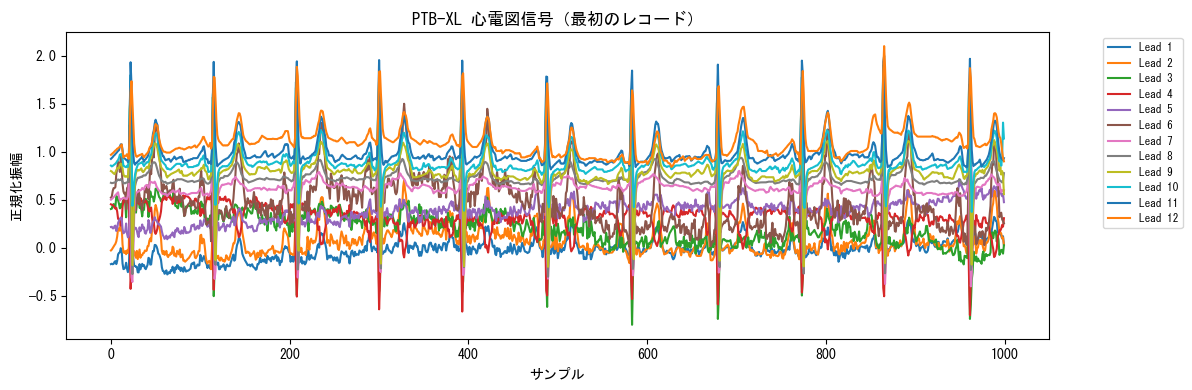

信号データ確認完了


In [3]:
# 信号データの確認
import matplotlib.pyplot as plt

# 信号データの読み込み（最初の列ecg_idをスキップ）
train_signals = pd.read_csv(DATA_DIR / "train_signal.csv", usecols=lambda x: x != 'ecg_id', nrows=1)
signal_cols = train_signals.shape[1]  # チャンネル数

print(f"信号チャンネル数: {signal_cols}")
print(f"サンプリング周波数: 100Hz")

# 最初のレコードの信号を可視化
first_record = pd.read_csv(DATA_DIR / "train_signal.csv")
# ecg_id列を除外して数値に変換
first_signal = first_record[first_record['ecg_id'] == 1].iloc[:, 1:13].astype(float).values.T

print(f"信号形状: {first_signal.shape}")
print(f"記録時間: {first_signal.shape[1]/100:.1f}秒")

plt.figure(figsize=(12, 4))
for i in range(12):
    signal_i = first_signal[i]
    max_val = np.max(np.abs(signal_i))
    if max_val > 1e-6:
        signal_norm = signal_i / max_val
    else:
        signal_norm = signal_i
    plt.plot(signal_norm + i*0.1, label=f'Lead {i+1}')
plt.title('PTB-XL 心電図信号（最初のレコード）')
plt.xlabel('サンプル')
plt.ylabel('正規化振幅')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print("信号データ確認完了")